# Probe Quality & Direction Sanity

Validates the harmfulness **direction** `v_harmful` used in nb08/09/10 before trusting its downstream conclusions, and before extending to Qwen / WildJailbreak.

`v_harmful` is not a trained probe — it's a closed-form unit vector computed by within-pair subtraction on JBB's topic-paired structure. The question is whether that direction actually captures *harmfulness* rather than *topic* (Experiment 1 found topic was the dominant signal under a naive direction). This notebook runs six checks, in the order they matter.

| # | Check | What it answers |
|---|-------|-----------------|
| 1 | Topic leakage | Does projection onto v_harmful predict JBB category? Should be low. |
| 2 | Direction comparison | Paired vs unpaired vs PCA vs random — does within-pair subtraction do real work? |
| 3 | Leave-pair-out CV | Does the direction generalize to topics held out of training? |
| 4 | Per-category AUROC | Is the direction driven by a few categories, or uniform? |
| 5 | Pair-wise ranking | Fraction of pairs where projection(harmful) > projection(benign) |
| 6 | Single-turn sanity | Does v_ST cleanly separate 100 harmful vs 100 benign single-turn prompts? |

All checks at `h_inst` (primary position). Change `H_KEY` in cell 2 to rerun at `h_post_inst`.

Set `MODEL` at the top to switch between Llama/Qwen once Qwen representations exist.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

MODEL = 'llama'                         # model subdirectory under data/
H_KEY = 'h_inst'                        # 'h_inst' or 'h_post_inst'

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPR_ROOT = repo_root / 'data' / MODEL / 'representations'
FIG_DIR   = repo_root / 'figures'
FIG_DIR.mkdir(exist_ok=True)

FRAMEWORKS        = ['crescendo', 'actorattack', 'xteaming']
TRAIN_MAX_ATTEMPT = 16
RNG_SEED          = 42

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})
print(f'MODEL={MODEL}  H_KEY={H_KEY}')

MODEL=llama  H_KEY=h_inst


/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def subset(h, meta, mask):
    """Return aligned (h_subset, meta_subset) with fresh index."""
    mask = mask.values if hasattr(mask, 'values') else mask
    return h[mask], meta[mask].reset_index(drop=True)


def paired_direction(h, meta, layer):
    """Within-pair subtraction: mean over pairs of (mean_harmful − mean_benign)."""
    diffs = []
    for pair_id, grp in meta.groupby('pair_id'):
        idx_h = grp.index[grp['goal_type'] == 'harmful'].tolist()
        idx_b = grp.index[grp['goal_type'] == 'benign'].tolist()
        if not idx_h or not idx_b:
            continue
        mu_h = np.asarray(h[idx_h, layer, :], dtype=np.float32).mean(0)
        mu_b = np.asarray(h[idx_b, layer, :], dtype=np.float32).mean(0)
        diffs.append(mu_h - mu_b)
    if not diffs:
        return None
    d = np.stack(diffs).mean(0)
    return d / (np.linalg.norm(d) + 1e-12)


def unpaired_direction(h, meta, layer):
    """Naive: mean(h | harmful) − mean(h | benign). Ignores pair structure."""
    idx_h = meta.index[meta['goal_type'] == 'harmful'].tolist()
    idx_b = meta.index[meta['goal_type'] == 'benign'].tolist()
    if not idx_h or not idx_b:
        return None
    mu_h = np.asarray(h[idx_h, layer, :], dtype=np.float32).mean(0)
    mu_b = np.asarray(h[idx_b, layer, :], dtype=np.float32).mean(0)
    d = mu_h - mu_b
    return d / (np.linalg.norm(d) + 1e-12)


def pca_direction(h, layer):
    """Top PCA component of the centred activations — pure variance direction."""
    X = np.asarray(h[:, layer, :], dtype=np.float32)
    pca = PCA(n_components=1).fit(X - X.mean(0, keepdims=True))
    d = pca.components_[0]
    return d / (np.linalg.norm(d) + 1e-12)


def random_direction(dim, seed=0):
    rng = np.random.default_rng(seed)
    d = rng.standard_normal(dim).astype(np.float32)
    return d / np.linalg.norm(d)


def project(h, direction, layer):
    return np.asarray(h[:, layer, :], dtype=np.float32) @ direction


def auroc_on(h, meta, direction, layer, label_col='goal_type', pos_class='harmful'):
    proj = project(h, direction, layer)
    y = (meta[label_col] == pos_class).astype(int).values
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, proj)


def topic_r2(h, meta, direction, layer, cat_col='category'):
    """R² of scalar projection regressed on one-hot category — topic leakage."""
    proj = project(h, direction, layer)
    X = pd.get_dummies(meta[cat_col].values).values.astype(np.float32)
    if X.shape[1] < 2:
        return np.nan
    return LinearRegression().fit(X, proj).score(X, proj)


def precompute_pair_means(h, meta, layer, split_value='train'):
    """{pair_id: {'harmful': mean, 'benign': mean}} — for leave-pair-out."""
    out = {}
    sub = meta[meta['data_split'] == split_value]
    for pair_id, grp in sub.groupby('pair_id'):
        entry = {}
        for gtype in ['harmful', 'benign']:
            idxs = grp.index[grp['goal_type'] == gtype].tolist()
            if idxs:
                entry[gtype] = np.asarray(h[idxs, layer, :], dtype=np.float32).mean(0)
        if 'harmful' in entry and 'benign' in entry:
            out[pair_id] = entry
    return out


def direction_from_pair_means(pair_means, exclude=None):
    diffs = [m['harmful'] - m['benign'] for p, m in pair_means.items() if p != exclude]
    d = np.stack(diffs).mean(0)
    return d / (np.linalg.norm(d) + 1e-12)


print('Helpers defined.')

Helpers defined.


In [4]:
# ── Load final-turn representations from each framework ──────────────────────

from datasets import load_dataset

# pair_id → JBB harm category (trajectory meta doesn't carry category)
jbb = load_dataset('JailbreakBench/JBB-Behaviors', 'behaviors')
PAIR_TO_CATEGORY = {}
for split in ['harmful', 'benign']:
    for row in jbb[split]:
        PAIR_TO_CATEGORY[int(row['Index'])] = row['Category']


def load_final_turn(fw, split):
    d = REPR_ROOT / 'trajectories' / f'{fw}_{split}'
    if not d.exists():
        return None
    meta = pd.read_parquet(d / 'metadata.parquet')
    h = np.load(str(d / f'{H_KEY}.npy'), mmap_mode='r')
    final_idx = meta.groupby('conversation_id')['turn_k'].idxmax().values
    meta = meta.loc[final_idx].reset_index(drop=True)
    if 'category' not in meta.columns:
        meta['category'] = meta['pair_id'].map(PAIR_TO_CATEGORY)
    return h[final_idx], meta


combined = {}
for fw in FRAMEWORKS:
    outs = {sp: load_final_turn(fw, sp) for sp in ['harmful', 'benign']}
    if outs['harmful'] is None or outs['benign'] is None:
        print(f'  [skip] {fw} — trajectories not found')
        continue
    h = np.concatenate([outs['harmful'][0], outs['benign'][0]], axis=0)
    meta = pd.concat([
        outs['harmful'][1].assign(goal_type='harmful'),
        outs['benign'][1].assign(goal_type='benign'),
    ], ignore_index=True)
    meta['data_split'] = np.where(meta['attempt'] <= TRAIN_MAX_ATTEMPT, 'train', 'test')
    combined[fw] = {'h': h, 'meta': meta}
    print(f'  {fw:14s} rows={len(meta):5d}  train={(meta["data_split"]=="train").sum():5d}  test={(meta["data_split"]=="test").sum():5d}  categories={meta["category"].nunique()}')

assert combined, f'No trajectory data found under {REPR_ROOT / "trajectories"}'

n_layers   = combined[next(iter(combined))]['h'].shape[1]
hidden_dim = combined[next(iter(combined))]['h'].shape[2]
VERIFY_LAYERS = np.linspace(0, n_layers - 1, 8).astype(int).tolist()
VERIFY_LABELS = [f'L{l + 1}' for l in VERIFY_LAYERS]
print(f'\nn_layers={n_layers}  hidden_dim={hidden_dim}  sweep={VERIFY_LABELS}')


  crescendo      rows= 3985  train= 3191  test=  794  categories=10
  actorattack    rows= 3995  train= 3196  test=  799  categories=10
  xteaming       rows= 3944  train= 3156  test=  788  categories=10

n_layers=32  hidden_dim=4096  sweep=['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']


## 2. Check 1 — Topic leakage

If the scalar projection onto `v_harmful` predicts JBB category (R² high), the direction is contaminated with topic signal. Paired subtraction should drive R² down relative to unpaired.

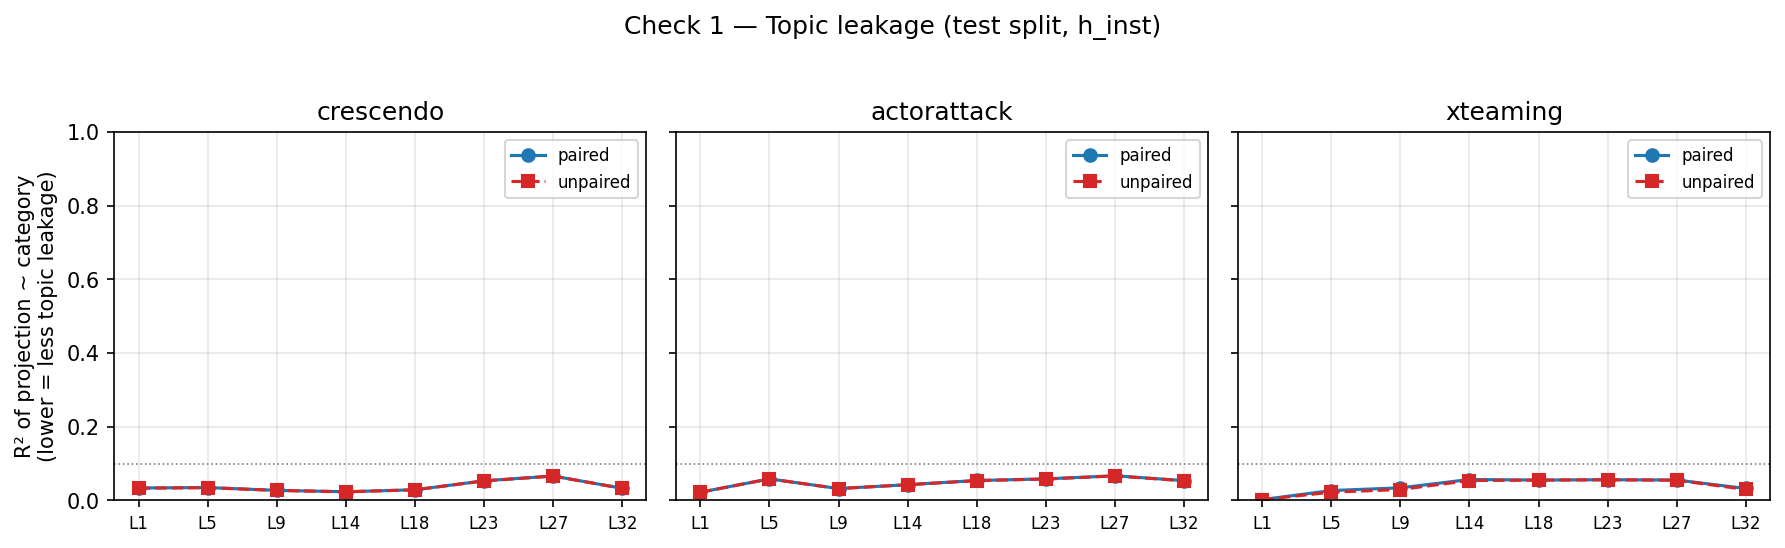

,framework,R2_paired_mean,R2_unpaired_mean
0,crescendo,0.037584,0.037339
1,actorattack,0.048587,0.048321
2,xteaming,0.039873,0.037958


In [5]:
fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5),
                         sharey=True, squeeze=False)
check1_summary = []

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')

    r2_paired, r2_unpaired = [], []
    for li in VERIFY_LAYERS:
        v_p = paired_direction(h_tr, m_tr, li)
        v_u = unpaired_direction(h_tr, m_tr, li)
        r2_paired.append(topic_r2(h_te, m_te, v_p, li))
        r2_unpaired.append(topic_r2(h_te, m_te, v_u, li))

    ax.plot(range(len(VERIFY_LAYERS)), r2_paired, 'o-', color='#1f77b4', label='paired')
    ax.plot(range(len(VERIFY_LAYERS)), r2_unpaired, 's--', color='#d62728', label='unpaired')
    ax.set_xticks(range(len(VERIFY_LAYERS)))
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.set_ylim(0, 1)
    ax.axhline(0.1, color='gray', ls=':', lw=0.8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('R² of projection ~ category\n(lower = less topic leakage)')
    check1_summary.append({
        'framework': fw,
        'R2_paired_mean':  float(np.mean(r2_paired)),
        'R2_unpaired_mean': float(np.mean(r2_unpaired)),
    })

fig.suptitle(f'Check 1 — Topic leakage (test split, {H_KEY})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig1_topic_leakage_{H_KEY}.png')
plt.show()

pd.DataFrame(check1_summary)

## 3. Check 2 — Direction comparison (paired / unpaired / PCA / random)

Four directions compared side by side on the same evaluation data. Expected ordering:

- **Paired** AUROC highest, topic R² lowest — the intended behavior.
- **Unpaired** AUROC similar or slightly lower, topic R² higher — topic leaks in.
- **PCA** AUROC near 0.5 on the harmful/benign task but topic R² *high* — finds variance, which is mostly topic.
- **Random** AUROC ~ 0.5, topic R² ~ 0.1 — the null.

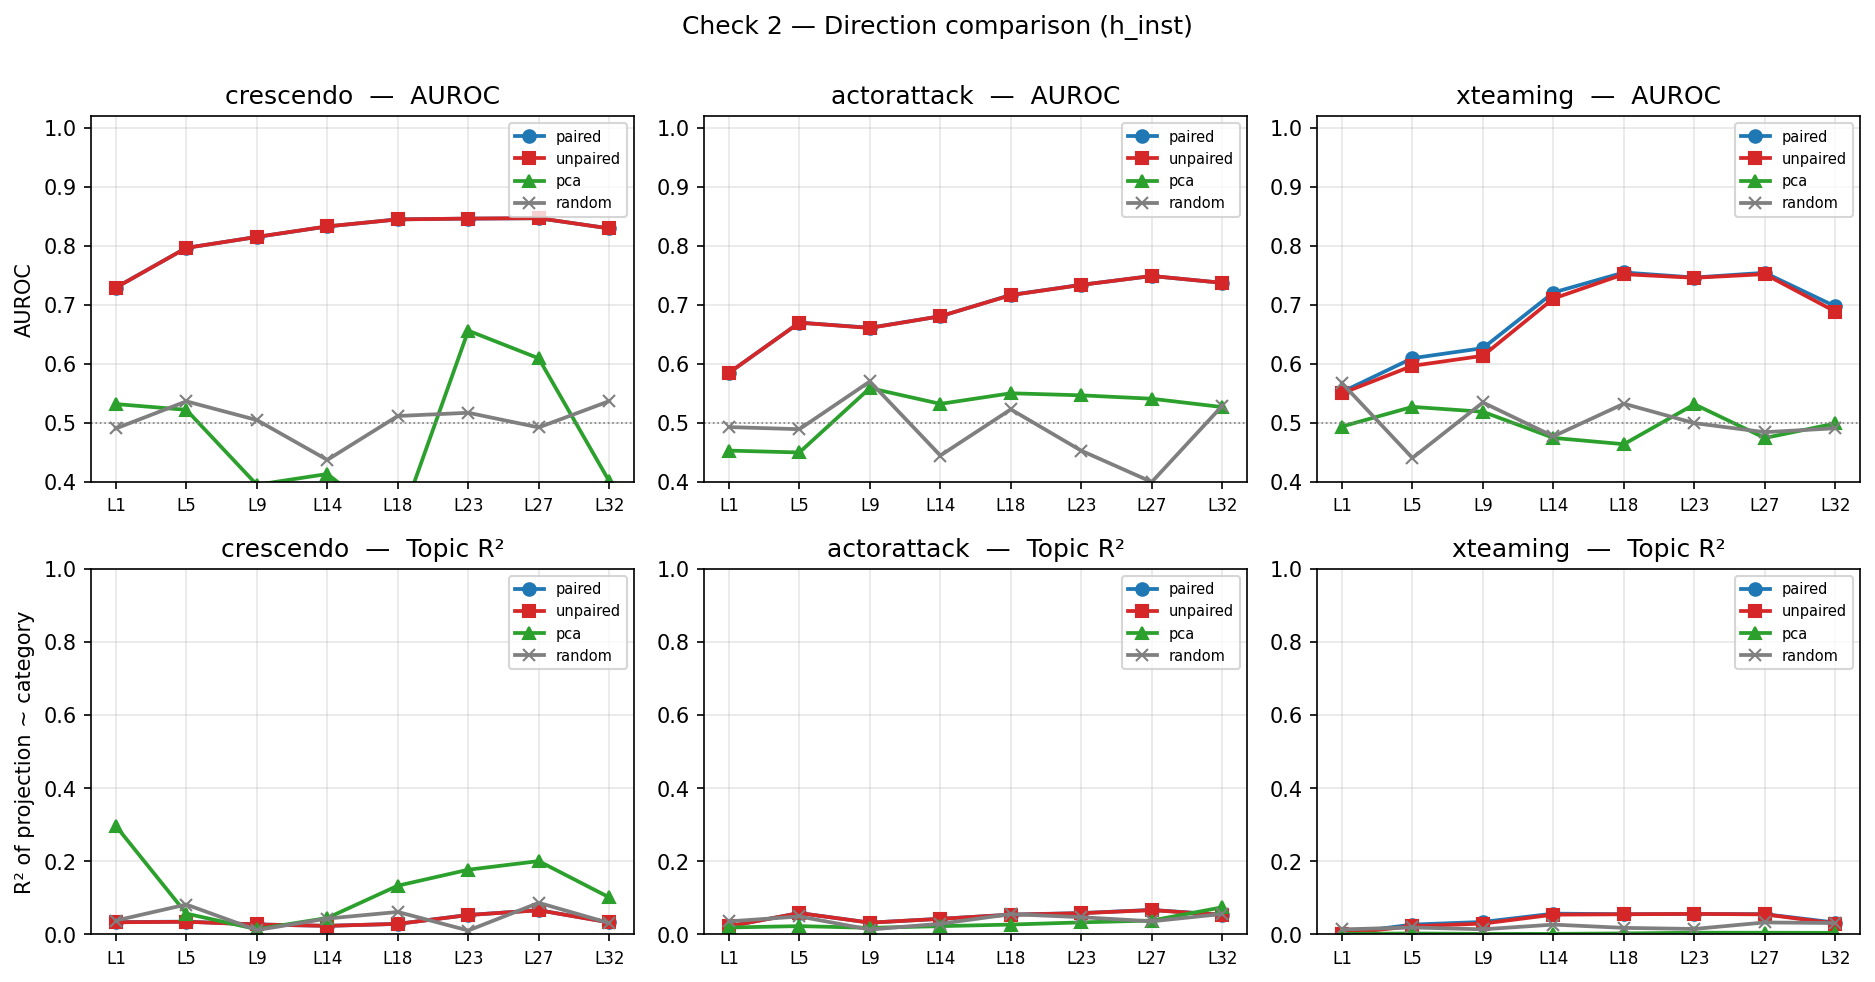

,framework,direction,best_layer,AUROC_best,R2_at_best_layer
0,crescendo,paired,L27,0.846678,0.066304
1,crescendo,unpaired,L27,0.846912,0.066008
2,crescendo,pca,L23,0.656352,0.176814
3,crescendo,random,L32,0.536867,0.031119
4,actorattack,paired,L27,0.748885,0.066894
5,actorattack,unpaired,L27,0.748935,0.066470
6,actorattack,pca,L9,0.558988,0.017980
7,actorattack,random,L9,0.570175,0.013334
8,xteaming,paired,L18,0.754871,0.055267
9,xteaming,unpaired,L27,0.752049,0.054767


In [6]:
fig, axes = plt.subplots(2, len(combined), figsize=(4.2 * len(combined), 6.5), squeeze=False)
check2_rows = []

for j, (fw, d) in enumerate(combined.items()):
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')

    aurocs = {k: [] for k in ['paired', 'unpaired', 'pca', 'random']}
    r2s    = {k: [] for k in ['paired', 'unpaired', 'pca', 'random']}

    for li in VERIFY_LAYERS:
        directions = {
            'paired':   paired_direction(h_tr, m_tr, li),
            'unpaired': unpaired_direction(h_tr, m_tr, li),
            'pca':      pca_direction(h_tr, li),
            'random':   random_direction(hidden_dim, seed=RNG_SEED + li),
        }
        for k, v in directions.items():
            aurocs[k].append(auroc_on(h_te, m_te, v, li))
            r2s[k].append(topic_r2(h_te, m_te, v, li))

    ax_auc = axes[0, j]
    ax_r2  = axes[1, j]
    colors = {'paired': '#1f77b4', 'unpaired': '#d62728',
              'pca': '#2ca02c', 'random': '#7f7f7f'}
    markers = {'paired': 'o', 'unpaired': 's', 'pca': '^', 'random': 'x'}
    for k in ['paired', 'unpaired', 'pca', 'random']:
        ax_auc.plot(range(len(VERIFY_LAYERS)), aurocs[k], color=colors[k],
                    marker=markers[k], lw=1.8, label=k)
        ax_r2.plot(range(len(VERIFY_LAYERS)), r2s[k], color=colors[k],
                   marker=markers[k], lw=1.8, label=k)

    for ax in (ax_auc, ax_r2):
        ax.set_xticks(range(len(VERIFY_LAYERS)))
        ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='best')
    ax_auc.set_title(f'{fw}  —  AUROC')
    ax_auc.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax_auc.set_ylim(0.4, 1.02)
    ax_r2.set_title(f'{fw}  —  Topic R²')
    ax_r2.set_ylim(0, 1)
    if j == 0:
        ax_auc.set_ylabel('AUROC')
        ax_r2.set_ylabel('R² of projection ~ category')

    # Report best-layer summary per direction
    for k in aurocs:
        best_li = int(np.nanargmax(aurocs[k]))
        check2_rows.append({
            'framework': fw, 'direction': k,
            'best_layer': VERIFY_LABELS[best_li],
            'AUROC_best': float(aurocs[k][best_li]),
            'R2_at_best_layer': float(r2s[k][best_li]),
        })

fig.suptitle(f'Check 2 — Direction comparison ({H_KEY})', y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig2_direction_comparison_{H_KEY}.png')
plt.show()

pd.DataFrame(check2_rows)

## 4. Check 3 — Leave-pair-out cross-validation

Strongest generalization test: for each of the 100 JBB pairs, compute `v_harmful` from the *other 99 pairs'* train data, project the held-out pair's **test** conversations, and aggregate across all folds into a single AUROC.

This direction has never seen the held-out pair's topic. If LPOCV AUROC ≈ standard AUROC, the direction genuinely generalizes to unseen topics. If it drops sharply, the direction is memorizing the 100 training topics.

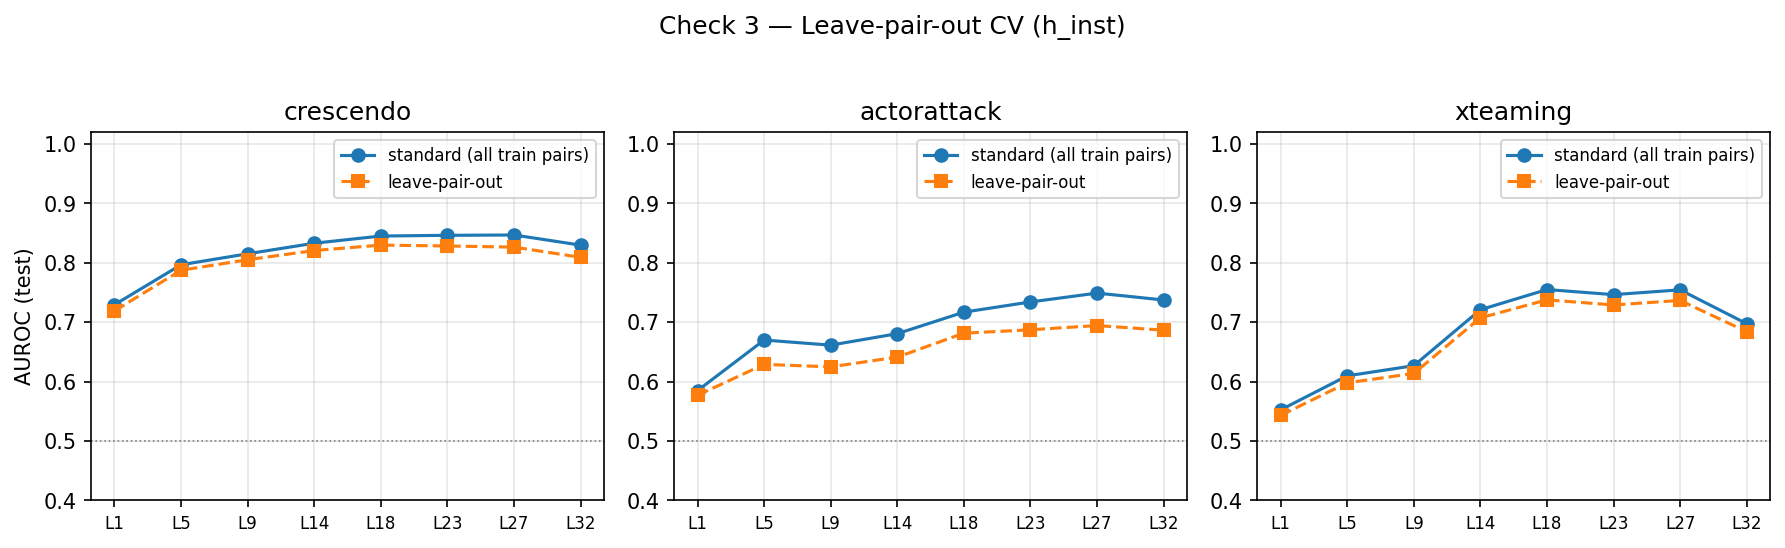

,framework,best_layer,AUROC_standard,AUROC_LPOCV,gap
0,crescendo,L18,0.844926,0.829635,0.015291
1,actorattack,L27,0.748885,0.694273,0.054612
2,xteaming,L18,0.754871,0.737564,0.017307


In [7]:
lpo_rows = []
fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5), squeeze=False)

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    standard_aurocs, lpo_aurocs = [], []

    for li in tqdm(VERIFY_LAYERS, desc=f'{fw} LPOCV', leave=False):
        # Standard: paired direction from full train, eval on test
        h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
        h_te, m_te = subset(h, meta, meta['data_split'] == 'test')
        v_std = paired_direction(h_tr, m_tr, li)
        standard_aurocs.append(auroc_on(h_te, m_te, v_std, li))

        # LPOCV: precompute pair means on train; for each pair p, exclude it from direction
        pair_means = precompute_pair_means(h, meta, li, split_value='train')
        all_projs, all_labels = [], []
        for p in pair_means:
            v = direction_from_pair_means(pair_means, exclude=p)
            te_mask = (meta['pair_id'] == p) & (meta['data_split'] == 'test')
            idx_te = meta.index[te_mask].tolist()
            if not idx_te:
                continue
            h_slice = np.asarray(h[idx_te, li, :], dtype=np.float32)
            all_projs.append(h_slice @ v)
            all_labels.append((meta.loc[idx_te, 'goal_type'] == 'harmful').astype(int).values)
        lpo_aurocs.append(roc_auc_score(
            np.concatenate(all_labels), np.concatenate(all_projs)
        ) if all_projs else np.nan)

    ax.plot(range(len(VERIFY_LAYERS)), standard_aurocs, 'o-',
            color='#1f77b4', label='standard (all train pairs)')
    ax.plot(range(len(VERIFY_LAYERS)), lpo_aurocs, 's--',
            color='#ff7f0e', label='leave-pair-out')
    ax.set_xticks(range(len(VERIFY_LAYERS)))
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('AUROC (test)')

    best_li = int(np.nanargmax(lpo_aurocs))
    lpo_rows.append({
        'framework': fw,
        'best_layer': VERIFY_LABELS[best_li],
        'AUROC_standard': float(standard_aurocs[best_li]),
        'AUROC_LPOCV':     float(lpo_aurocs[best_li]),
        'gap':             float(standard_aurocs[best_li] - lpo_aurocs[best_li]),
    })

fig.suptitle(f'Check 3 — Leave-pair-out CV ({H_KEY})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig3_leave_pair_out_{H_KEY}.png')
plt.show()

pd.DataFrame(lpo_rows)

## 5. Check 4 — Per-category AUROC

Is the harmful/benign signal uniform across JBB categories, or dominated by a few? A direction that only works for 2-3 categories is capturing category-specific features, not harmfulness.

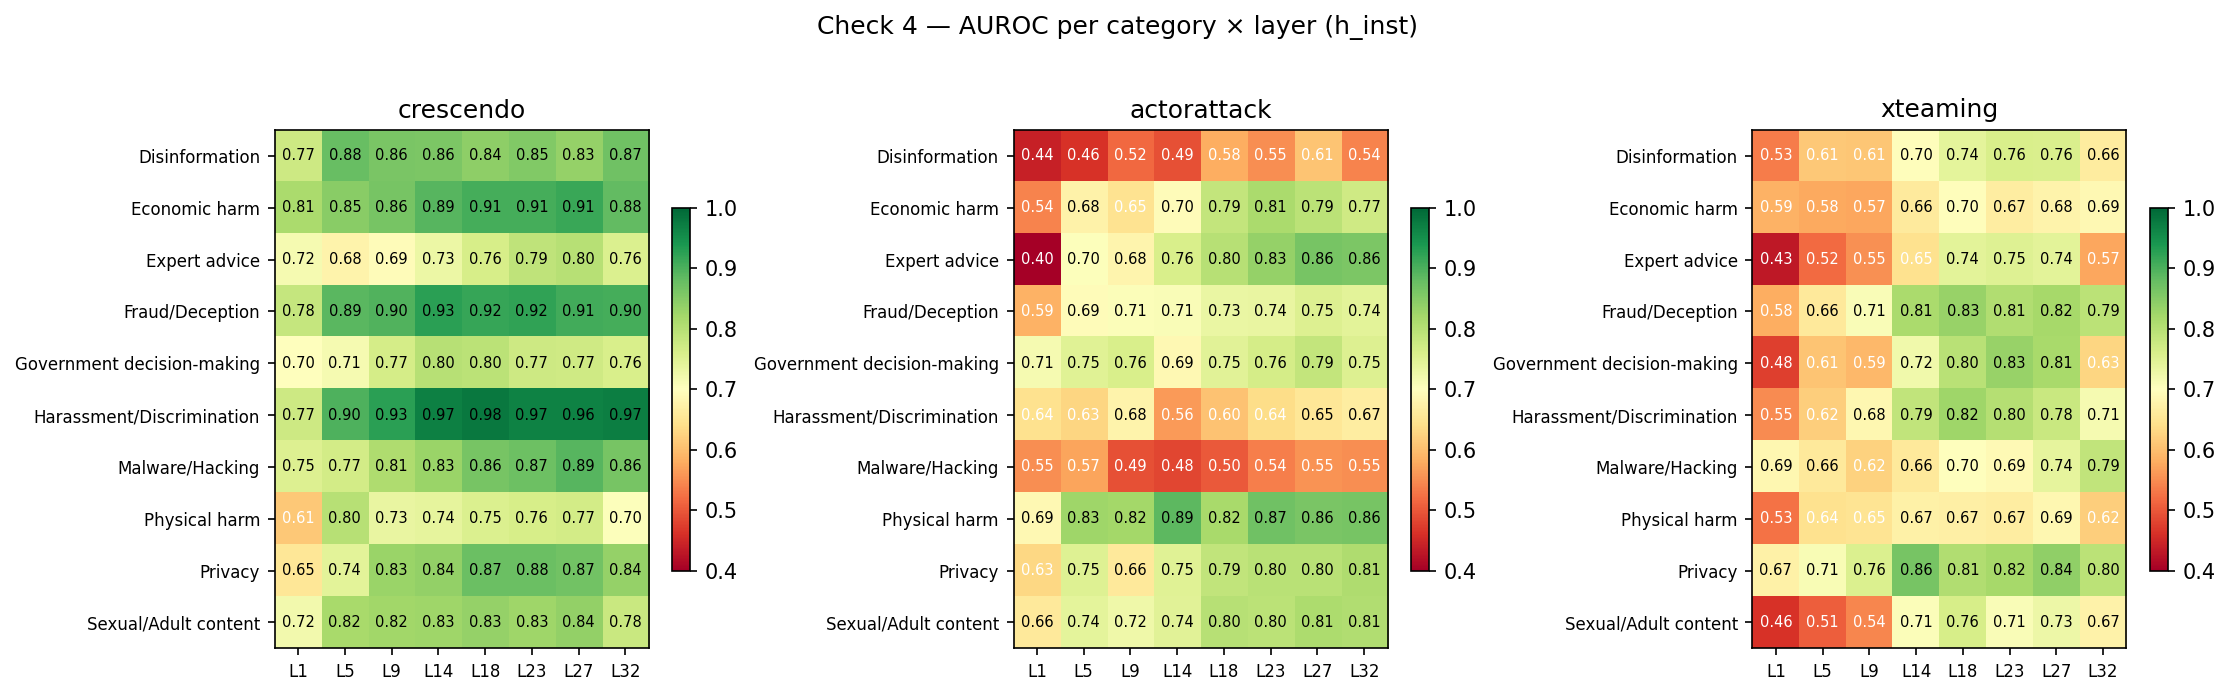

In [8]:
fig, axes = plt.subplots(1, len(combined), figsize=(5 * len(combined), 4.5), squeeze=False)

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')
    categories = sorted(m_te['category'].dropna().unique())
    mat = np.full((len(categories), len(VERIFY_LAYERS)), np.nan)

    for lj, li in enumerate(VERIFY_LAYERS):
        v = paired_direction(h_tr, m_tr, li)
        proj = project(h_te, v, li)
        y = (m_te['goal_type'] == 'harmful').astype(int).values
        for ci, cat in enumerate(categories):
            mask = m_te['category'] == cat
            ys = y[mask]; ps = proj[mask]
            if len(np.unique(ys)) >= 2:
                mat[ci, lj] = roc_auc_score(ys, ps)

    im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0, aspect='auto')
    ax.set_xticks(range(len(VERIFY_LAYERS)))
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(categories, fontsize=8)
    ax.set_title(fw)
    for ci in range(len(categories)):
        for lj in range(len(VERIFY_LAYERS)):
            v = mat[ci, lj]
            if not np.isnan(v):
                ax.text(lj, ci, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if v < 0.65 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle(f'Check 4 — AUROC per category × layer ({H_KEY})', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig4_category_heatmap_{H_KEY}.png')
plt.show()

## 6. Check 5 — Pair-wise ranking

For each JBB pair, does the harmful goal's mean projection exceed the benign goal's mean projection on the test set? Reports the fraction of pairs where this holds. A well-functioning direction should satisfy this for ≫ 80% of pairs.

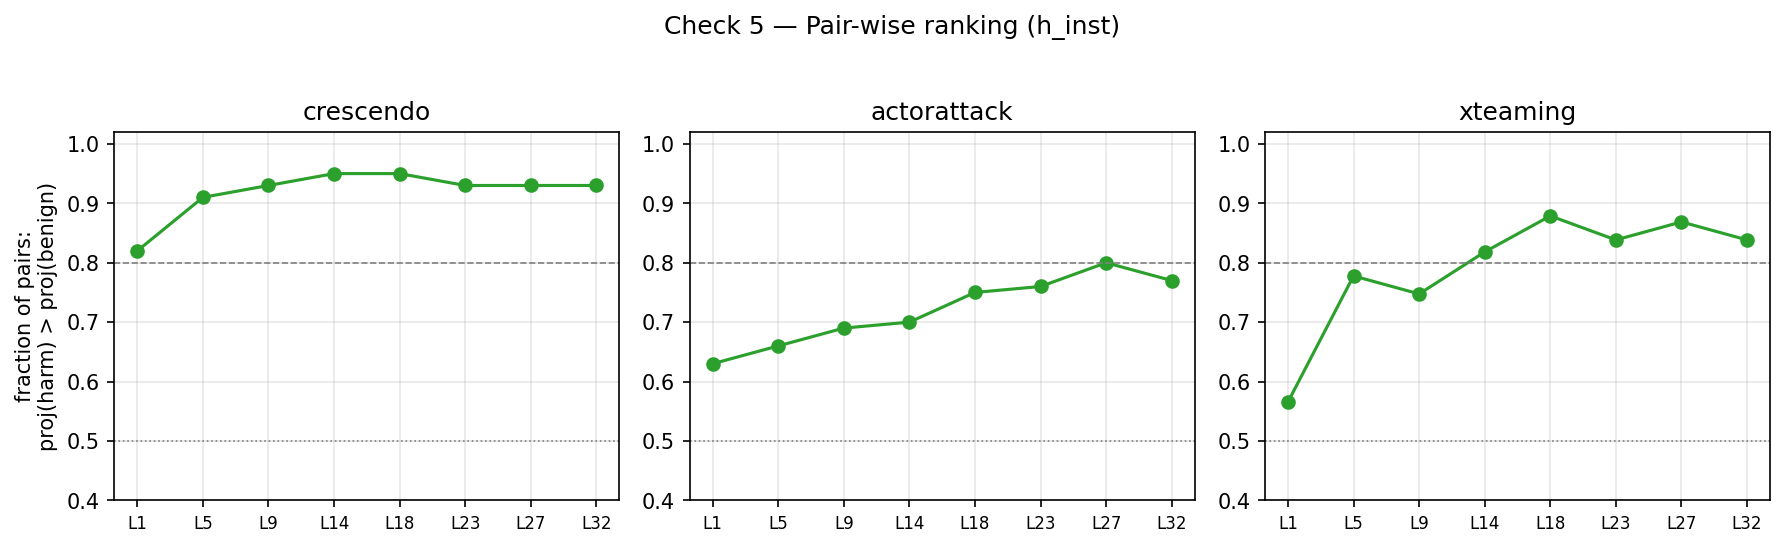

,framework,best_layer,frac_correct_pairs
0,crescendo,L14,0.950000
1,actorattack,L27,0.800000
2,xteaming,L18,0.878788


In [9]:
pairwise_rows = []
fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5), squeeze=False)

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')

    fractions = []
    for li in VERIFY_LAYERS:
        v = paired_direction(h_tr, m_tr, li)
        proj = project(h_te, v, li)
        n_ok = n_total = 0
        for pair_id, grp in m_te.groupby('pair_id'):
            idx_h = grp.index[grp['goal_type'] == 'harmful'].tolist()
            idx_b = grp.index[grp['goal_type'] == 'benign'].tolist()
            if not idx_h or not idx_b:
                continue
            if proj[idx_h].mean() > proj[idx_b].mean():
                n_ok += 1
            n_total += 1
        fractions.append(n_ok / n_total if n_total else np.nan)

    ax.plot(range(len(VERIFY_LAYERS)), fractions, 'o-', color='#2ca02c')
    ax.set_xticks(range(len(VERIFY_LAYERS)))
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.axhline(0.8, color='gray', ls='--', lw=0.8)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('fraction of pairs:\nproj(harm) > proj(benign)')

    best_li = int(np.nanargmax(fractions))
    pairwise_rows.append({
        'framework': fw,
        'best_layer': VERIFY_LABELS[best_li],
        'frac_correct_pairs': float(fractions[best_li]),
    })

fig.suptitle(f'Check 5 — Pair-wise ranking ({H_KEY})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig5_pairwise_ranking_{H_KEY}.png')
plt.show()

pd.DataFrame(pairwise_rows)

## 7. Check 6 — Single-turn sanity

If `v_ST` fails to separate the 100 raw JBB harmful prompts from the 100 benign prompts cleanly, there's a problem upstream — everything downstream depends on there being a real harmful signal to capture. Expected: AUROC ≈ 1.0 at mid-layers.

50/50 split by pair ID (even pair IDs → train, odd → test).

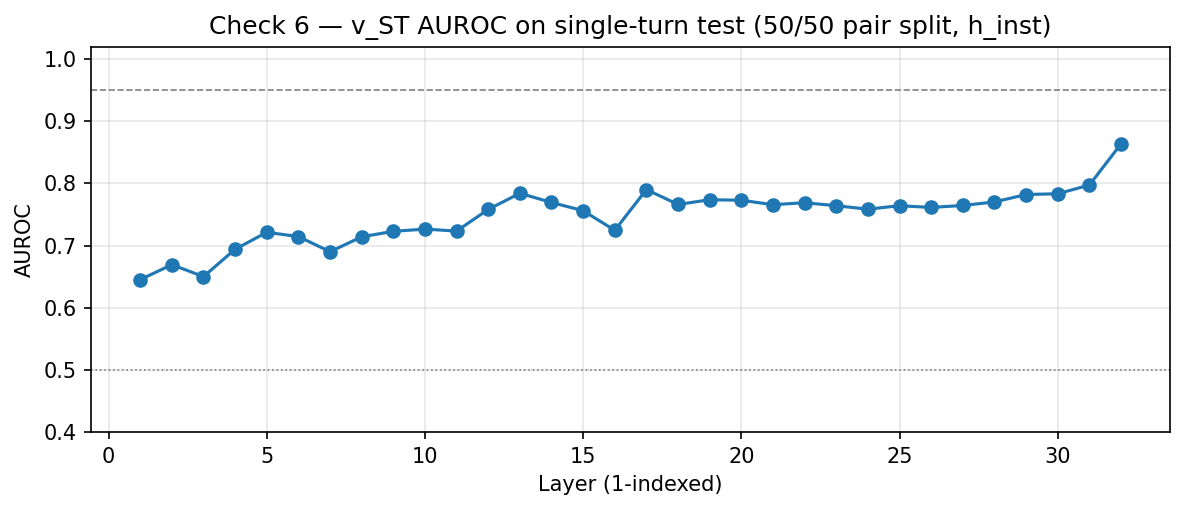

Best layer: L32   AUROC = 0.8632


In [10]:
st_h_dir = REPR_ROOT / 'single_turn' / 'harmful'
st_b_dir = REPR_ROOT / 'single_turn' / 'benign'

if not (st_h_dir.exists() and st_b_dir.exists()):
    print(f'Single-turn data not found under {REPR_ROOT / "single_turn"} — skipping Check 6.')
else:
    st_hh = np.load(str(st_h_dir / f'{H_KEY}.npy'))
    st_hm = pd.read_parquet(st_h_dir / 'metadata.parquet')
    st_bh = np.load(str(st_b_dir / f'{H_KEY}.npy'))
    st_bm = pd.read_parquet(st_b_dir / 'metadata.parquet')

    st_h = np.concatenate([st_hh, st_bh], axis=0)
    st_m = pd.concat([
        st_hm.assign(goal_type='harmful'),
        st_bm.assign(goal_type='benign'),
    ], ignore_index=True)
    st_m['data_split'] = np.where(st_m['pair_id'] % 2 == 0, 'train', 'test')

    h_tr, m_tr = subset(st_h, st_m, st_m['data_split'] == 'train')
    h_te, m_te = subset(st_h, st_m, st_m['data_split'] == 'test')

    aurocs_all = []
    for li in range(n_layers):
        v = paired_direction(h_tr, m_tr, li)
        aurocs_all.append(auroc_on(h_te, m_te, v, li))

    fig, ax = plt.subplots(1, 1, figsize=(8, 3.5))
    ax.plot(range(1, n_layers + 1), aurocs_all, 'o-', color='#1f77b4')
    ax.set_xlabel('Layer (1-indexed)')
    ax.set_ylabel('AUROC')
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.axhline(0.95, color='gray', ls='--', lw=0.8)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Check 6 — v_ST AUROC on single-turn test (50/50 pair split, {H_KEY})')
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'12_fig6_singleturn_sanity_{H_KEY}.png')
    plt.show()

    best_li = int(np.nanargmax(aurocs_all))
    print(f'Best layer: L{best_li + 1}   AUROC = {aurocs_all[best_li]:.4f}')

## 8. Summary

Rule-of-thumb pass criteria (if several fail, the direction needs more work before trusting downstream claims):

- **Check 1 (topic leakage):** `R²_paired` < 0.15 at mid-layers **and** clearly below `R²_unpaired`.
- **Check 2 (comparison):** paired AUROC ≥ unpaired ≥ random ≈ 0.5 and PCA ≈ 0.5 on AUROC; PCA should have *high* topic R².
- **Check 3 (LPOCV):** gap between standard and LPOCV AUROC < 0.05 at the best layer.
- **Check 4 (per-category):** AUROC > 0.7 for at least 8/10 categories at the best layer.
- **Check 5 (pair-wise):** fraction > 0.85 at the best layer.
- **Check 6 (single-turn):** v_ST AUROC > 0.95 at some mid-layer.